#### phân cụm 3 điểm số
###### Bài tập: 1) nộp bảng điểm cho lớp trưởng; 2) phân cum lớp thành 3 nhóm; 3) mỗi cá nhân nộp link code github, video chạy chương trình (link video youtube để trong github).

In [26]:
# Import thư viện và Thiết lập cấu hình hiển thị tiếng Việt cho Biểu đồ
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import openpyxl
import matplotlib.font_manager as fm
import os
import subprocess # To run shell commands and check return codes

# Cài đặt font để hiển thị tiếng Việt trên biểu đồ trong Colab
font_path = 'Roboto-Regular.ttf'
font_url = 'https://github.com/google/fonts/raw/main/ofl/roboto/Roboto-Regular.ttf'

print(f"Attempting to download font to: {font_path}")
# Execute wget and capture its return code
try:
    # Use subprocess.run to execute the command and get the return code
    # `check=True` raises an exception if the command returns a non-zero exit code.
    result = subprocess.run(['wget', '-O', font_path, font_url], check=True, capture_output=True)
    print(f"Wget command executed successfully. Stdout: {result.stdout.decode().strip()}, Stderr: {result.stderr.decode().strip()}")
    wget_success = True
except subprocess.CalledProcessError as e:
    print(f"Wget command failed with error: {e}")
    print(f"Stderr: {e.stderr.decode().strip()}")
    wget_success = False

font_configured_successfully = False
if wget_success and os.path.exists(font_path) and os.path.getsize(font_path) > 0:
    print(f"Font file '{font_path}' downloaded and verified. Attempting to load.")
    try:
        # Add the font to Matplotlib's font manager
        fm.fontManager.addfont(font_path)
        # Set the font family for plots (ensure it's recognized by checking ttflist)
        if 'Roboto-Regular' in [f.name for f in fm.fontManager.ttflist]:
            plt.rcParams['font.family'] = 'Roboto-Regular'
            print(f"Font 'Roboto-Regular' loaded and configured successfully for Matplotlib.")
            font_configured_successfully = True
        else:
            print(f"Warning: Font '{font_path}' was added but 'Roboto-Regular' not found in ttflist. Using default font.")
    except Exception as e:
        print(f"Error loading font '{font_path}' into font manager: {e}. Using default font.")
else:
    print(f"Error: Font file '{font_path}' was not successfully downloaded or is invalid.")

# Always ensure a working font is set, even if custom font failed
if not font_configured_successfully:
    print("Falling back to a robust default font (sans-serif) for plots.")
    plt.rcParams['font.family'] = 'sans-serif' # A common and generally safe default

print(f"Current Matplotlib font family setting: {plt.rcParams['font.family']}")
print("Đã chuẩn bị xong thư viện và cấu hình font!")

Attempting to download font to: Roboto-Regular.ttf
Wget command failed with error: Command '['wget', '-O', 'Roboto-Regular.ttf', 'https://github.com/google/fonts/raw/main/ofl/roboto/Roboto-Regular.ttf']' returned non-zero exit status 8.
Stderr: --2026-05-26 09:38:18--  https://github.com/google/fonts/raw/main/ofl/roboto/Roboto-Regular.ttf
Resolving github.com (github.com)... 140.82.121.4
Connecting to github.com (github.com)|140.82.121.4|:443... connected.
HTTP request sent, awaiting response... 404 Not Found
2026-05-26 09:38:18 ERROR 404: Not Found.
Error: Font file 'Roboto-Regular.ttf' was not successfully downloaded or is invalid.
Falling back to a robust default font (sans-serif) for plots.
Current Matplotlib font family setting: ['sans-serif']
Đã chuẩn bị xong thư viện và cấu hình font!


In [27]:
# ĐỌC DỮ LIỆU
# Sử dụng file csv được chuyển đổi từ xlsx đặt tại đường dẫn /var
file_path = "/TỔNG HỢP ĐIỂM K58KTP.xlsx"

# Đọc file bỏ qua lỗi mã hóa nếu có
df_raw = pd.read_excel(file_path, header=None)

print(f"Kích thước dữ liệu gốc: {df_raw.shape}")

# 1. Trích xuất thông tin sinh viên từ các dòng đầu (bắt đầu từ cột thứ 4 trở đi)
mssv_row = df_raw.iloc[1, 3:].values
tensv_row = df_raw.iloc[2, 3:].values

# 2. Trích xuất số tín chỉ của từng môn học (Dòng số 3, từ cột số 4 trở đi)
# Lưu ý: Điểm số của môn bắt đầu tính từ dòng số 4
tin_chi_raw = df_raw.iloc[3, 3:].values
# Đổi dấu phẩy thành dấu chấm (nếu có) và chuyển về dạng số, lỗi tự động chuyển thành NaN
tin_chi_series = pd.to_numeric(pd.Series(tin_chi_raw).astype(str).str.replace(',', '.', regex=True), errors='coerce')
# Điền giá trị mặc định là 2 tín chỉ cho các môn bị khuyết số TC
tin_chi = tin_chi_series.fillna(2.0).values

print(f"Số lượng sinh viên ban đầu: {len(mssv_row)}")
print(f"Số lượng môn học ghi nhận số tín chỉ: {len(tin_chi)}")

Kích thước dữ liệu gốc: (56, 75)
Số lượng sinh viên ban đầu: 72
Số lượng môn học ghi nhận số tín chỉ: 72


In [28]:
# XỬ LÝ MA TRẬN ĐIỂM & ĐỒNG BỘ TÍN CHỈ ĐỂ TÍN GPA
# ==============================================================================

# Re-extract tin_chi correctly from df_raw for the courses (rows)
# The credit values are in df_raw.iloc[4:, 2]
correct_tin_chi_series = pd.to_numeric(df_raw.iloc[4:, 2].astype(str).str.replace(',', '.', regex=True), errors='coerce')
tin_chi = correct_tin_chi_series.fillna(2.0).values # Ensure tin_chi is correctly updated, now it will have 52 elements

# 1. Lấy ma trận điểm gốc (Dòng 4 trở đi, Cột 3 trở đi)
students_df = df_raw.iloc[4:, 3:].copy()

# Đồng bộ định dạng số thập phân (thay ',' bằng '.')
students_df = students_df.replace(',', '.', regex=True)
students_df = students_df.apply(pd.to_numeric, errors='coerce')

# 2. Xử lý lọc bỏ MÔN HỌC (Hàng) bị trống hoàn toàn nếu có
# (Vì dữ liệu của m Hàng là Môn học, nên ta kiểm tra theo hàng: axis=1)
rows_to_drop = students_df.index[students_df.isna().all(axis=1)]
students_df_filtered = students_df.drop(index=rows_to_drop)

# Đồng bộ loại bỏ số tín chỉ của những môn học bị xóa này
tin_chi_filtered = np.delete(tin_chi, [r - 4 for r in rows_to_drop])

# 3. Xử lý lọc bỏ SINH VIÊN (Cột) bị trống hoàn toàn nếu có
cols_to_drop = students_df_filtered.columns[students_df_filtered.isna().all(axis=0)]
students_df_filtered = students_df_filtered.drop(columns=cols_to_drop)

# Đồng bộ loại bỏ MSSV và Tên tương ứng của các cột sinh viên bị xóa
indices_to_drop = [c - 3 for c in cols_to_drop]
mssv_filtered = np.delete(mssv_row, indices_to_drop)
tensv_filtered = np.delete(tensv_row, indices_to_drop)

# 4. Điền điểm 0.0 vào các ô sinh viên khuyết điểm (bỏ thi/chưa học)
students_df_final = students_df_filtered.fillna(0.0)

# --- KIỂM TRA ĐỒNG BỘ TRƯỚC KHI TÍNH ---
num_courses = students_df_final.shape[0]
num_credits = len(tin_chi_filtered)

print(f"Số lượng môn học hiện tại trong ma trận điểm: {num_courses}")
print(f"Số lượng tín chỉ sau khi đồng bộ bộ lọc: {num_credits}")

if num_courses != num_credits:
    raise ValueError(f"Vẫn lệch cấu trúc! Ma trận có {num_courses} môn nhưng có {num_credits} tín chỉ.")

# --- ÁP DỤNG CÔNG THỨC GPA TÍN CHỈ CHUẨN ---
# Chuyển mảng số tín chỉ đã lọc thành ma trận cột đứng (67 môn x 1 cột)
tin_chi_column = tin_chi_filtered.reshape(-1, 1)

# Nhân từng điểm môn học với số tín chỉ tương ứng của môn đó
diem_nhan_tin_chi = students_df_final.values * tin_chi_column

# GPA = Tổng (Điểm * Tín chỉ) / Tổng số tín chỉ của các môn còn lại
gpa_scores = np.sum(diem_nhan_tin_chi, axis=0) / np.sum(tin_chi_filtered)

# Đóng gói thành DataFrame hành vi học tập của Sinh Viên
features_filtered = pd.DataFrame({
    'MSSV': mssv_filtered,
    'Ten_SV': tensv_filtered,
    'GPA': gpa_scores
})

print(f"\nSố sinh viên hợp lệ sau bộ lọc: {len(features_filtered)}")
print("\nXem trước bảng dữ liệu GPA tích lũy tính theo tín chỉ:")
print(features_filtered.head(10))

Số lượng môn học hiện tại trong ma trận điểm: 52
Số lượng tín chỉ sau khi đồng bộ bộ lọc: 52

Số sinh viên hợp lệ sau bộ lọc: 67

Xem trước bảng dữ liệu GPA tích lũy tính theo tín chỉ:
            MSSV            Ten_SV       GPA
0  K225480106002   Nguyễn Tuấn Anh  1.101562
1  K225480106095   Nguyễn Tuấn Anh  2.139063
2  K225510201001      Bùi Ngọc Anh  1.195312
3  K225480106082       Vũ Việt Anh  2.015625
4  K225480106001       Lê Tuấn Anh  2.379688
5  K225480106100      Lý Văn Cường  3.016406
6  K225480106008  Nguyễn Khánh Duy  2.375781
7  K225480106007  Nguyễn Thế Dương  2.646875
8  K225480106093  Nguyễn Đức Dương  3.215625
9  K225480106003     Đặng Đình Đạt  2.841406


/tmp/ipykernel_13498/2333247692.py:13: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  students_df = students_df.replace(',', '.', regex=True)


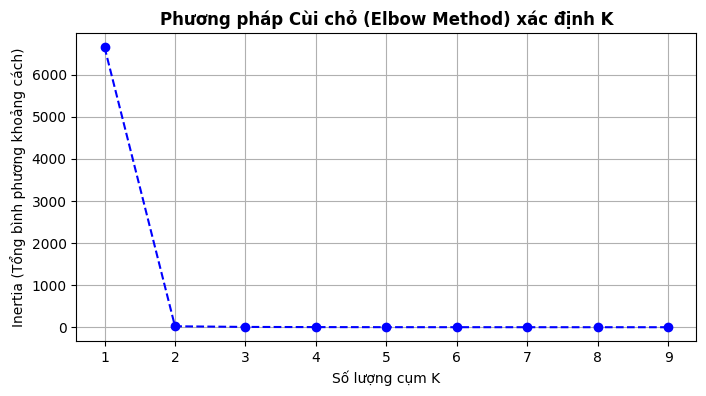

In [29]:
# PHƯƠNG PHÁP ELBOW METHOD
X = features_filtered[['GPA']].values
inertia = []
K = range(1, 10)

for k in K:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X)
    inertia.append(model.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(K, inertia, marker='o', color='b', linestyle='--')
plt.title("Phương pháp Cùi chỏ (Elbow Method) xác định K", fontsize=12, fontweight='bold')
plt.xlabel("Số lượng cụm K")
plt.ylabel("Inertia (Tổng bình phương khoảng cách)")
plt.grid(True)
plt.show()

In [30]:
# PHÂN CỤM K-MEANS
# Tiến hành phân cụm thành 3 nhóm tương ứng với 3 mức học lực
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
features_filtered['Cluster_Label'] = kmeans.fit_predict(X)

# Tự động gán nhãn dựa trên giá trị trung bình GPA tăng dần của cụm
cluster_means = features_filtered.groupby('Cluster_Label')['GPA'].mean().sort_values()

cluster_names = {
    cluster_means.index[0]: "Trung bình / Yếu",
    cluster_means.index[1]: "Khá",
    cluster_means.index[2]: "Giỏi"
}

features_filtered['Ten_Nhom_Cum'] = features_filtered['Cluster_Label'].map(cluster_names)

print("Thống kê số lượng sinh viên theo từng nhóm học lực:")
print(features_filtered['Ten_Nhom_Cum'].value_counts())

Thống kê số lượng sinh viên theo từng nhóm học lực:
Ten_Nhom_Cum
Khá                 38
Trung bình / Yếu    28
Giỏi                 1
Name: count, dtype: int64


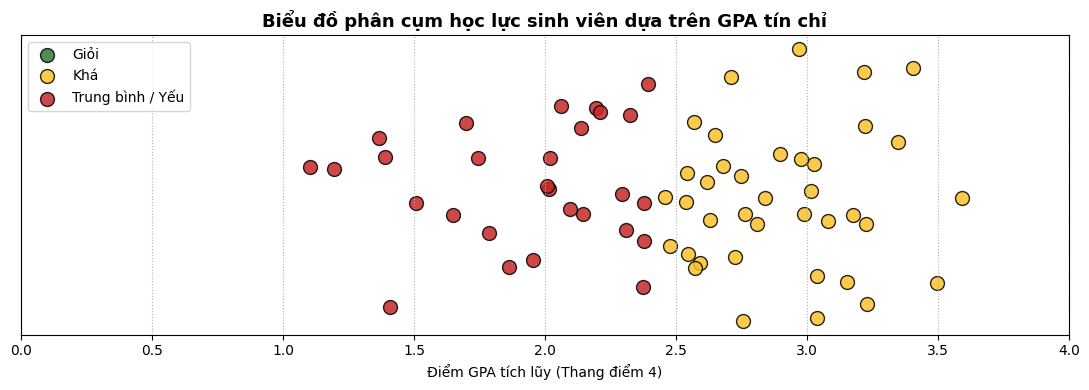

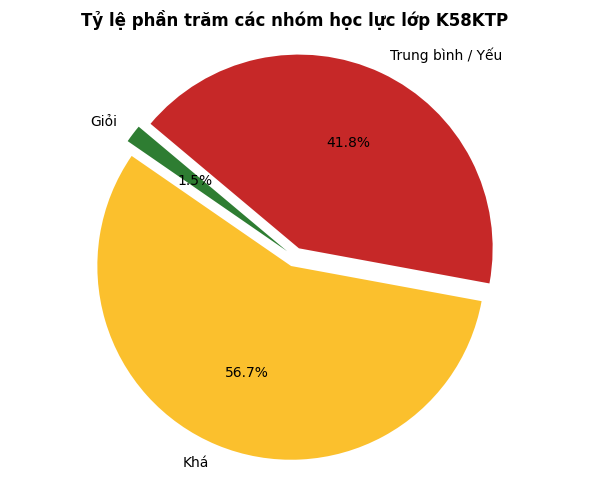

In [31]:
# VẼ BIỂU ĐỒ TRỰC QUAN HÓA KẾT QUẢ
# 1. Biểu đồ phân tán (Scatter Plot) phân cụm GPA kèm Jitter nhiễu để dễ nhìn điểm trùng
np.random.seed(42)
plt.figure(figsize=(11, 4))

colors_map = {"Giỏi": '#2E7D32', "Khá": '#FBC02D', "Trung bình / Yếu": '#C62828'}
groups = ["Giỏi", "Khá", "Trung bình / Yếu"]

for group_name in groups:
    sub_df = features_filtered[features_filtered['Ten_Nhom_Cum'] == group_name]
    y_jitter = np.random.normal(0, 0.05, size=len(sub_df)) # Tạo nhiễu trục Y để các chấm không đè lên nhau

    plt.scatter(
        sub_df['GPA'], y_jitter,
        c=colors_map[group_name], label=group_name,
        s=100, edgecolors='black', alpha=0.85
    )

plt.title('Biểu đồ phân cụm học lực sinh viên dựa trên GPA tín chỉ', fontsize=13, fontweight='bold')
plt.xlabel('Điểm GPA tích lũy (Thang điểm 4)')
plt.xlim(0.0, 4.0)
plt.gca().get_yaxis().set_visible(False) # Ẩn trục Y vì chỉ phân hóa theo trục X (GPA)
plt.grid(axis='x', linestyle=':')
plt.legend()
plt.tight_layout()
plt.show()

# 2. Biểu đồ tròn (Pie Chart) thể hiện tỷ lệ phần trăm
counts = [features_filtered[features_filtered['Ten_Nhom_Cum'] == l].shape[0] for l in groups]

plt.figure(figsize=(6, 5))
plt.pie(counts, labels=groups, autopct='%1.1f%%', colors=[colors_map[g] for g in groups], startangle=140, explode=(0.05, 0.05, 0.05))
plt.title('Tỷ lệ phần trăm các nhóm học lực lớp K58KTP', fontsize=12, fontweight='bold')
plt.axis('equal')
plt.tight_layout()
plt.show()

In [32]:
# SẮP XẾP VÀ XUẤT FILE BÁO CÁO (CSV & EXCEL)
import openpyxl
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

# Cấu hình độ ưu tiên để sắp xếp danh sách
priority_map = {"Giỏi": 0, "Khá": 1, "Trung bình / Yếu": 2}
features_filtered['Priority'] = features_filtered['Ten_Nhom_Cum'].map(priority_map)

# Sắp xếp: Nhóm Giỏi lên trước, trong từng nhóm ai GPA cao hơn đứng trước
features_filtered = features_filtered.sort_values(by=['Priority', 'GPA'], ascending=[True, False]).reset_index(drop=True)

# 1. Xuất file CSV dự phòng
features_filtered.to_csv("ket_qua_phan_cum_gpa.csv", index=False, encoding='utf-8-sig')

# 2. Tạo file Excel định dạng chuyên nghiệp bằng Openpyxl
wb = openpyxl.Workbook()
ws = wb.active
ws.title = "Phan Cum GPA"

# Khai báo style
HEADER_FILL = PatternFill(start_color="1F497D", end_color="1F497D", fill_type="solid")
FONT_HEADER = Font(bold=True, color="FFFFFF")
CENTER = Alignment(horizontal="center", vertical="center")
thin_border = Border(left=Side(style='thin', color='CCCCCC'),
                     right=Side(style='thin', color='CCCCCC'),
                     top=Side(style='thin', color='CCCCCC'),
                     bottom=Side(style='thin', color='CCCCCC'))

# Tiêu đề bảng
ws.merge_cells("A1:E1")
ws["A1"] = "DANH SÁCH PHÂN CỤM HỌC LỰC SINH VIÊN (GPA TÍN CHỈ)"
ws["A1"].font = Font(bold=True, size=14, color="1F497D")
ws["A1"].alignment = CENTER

# Headers cột
headers = ["STT", "MSSV", "Tên Sinh Viên", "GPA Tín Chỉ", "Nhóm Học Lực"]
for col, h in enumerate(headers, 1):
    cell = ws.cell(row=3, column=col, value=h)
    cell.fill = HEADER_FILL
    cell.font = FONT_HEADER
    cell.alignment = CENTER
    cell.border = thin_border

# Ghi dữ liệu vào file
for idx, row in features_filtered.iterrows():
    data_row = [idx + 1, row['MSSV'], row['Ten_SV'], round(row['GPA'], 2), row['Ten_Nhom_Cum']]
    for col, val in enumerate(data_row, 1):
        cell = ws.cell(row=idx + 4, column=col, value=val)
        cell.border = thin_border
        if col != 3: # Cột tên căn lề trái, các cột khác căn giữa
            cell.alignment = CENTER

# Thiết lập độ rộng cột tự động trực quan
ws.column_dimensions['A'].width = 8
ws.column_dimensions['B'].width = 18
ws.column_dimensions['C'].width = 30
ws.column_dimensions['D'].width = 15
ws.column_dimensions['E'].width = 25

# Lưu file kết quả tại thư mục hiện hành của Colab
output_file = "Ket_Qua_Phan_Cum_Moi.xlsx"
wb.save(output_file)

print(f"Xử lý thành công! Đã xuất các file báo cáo:\n1. 'ket_qua_phan_cum_gpa.csv'\n2. '{output_file}'")

Xử lý thành công! Đã xuất các file báo cáo:
1. 'ket_qua_phan_cum_gpa.csv'
2. 'Ket_Qua_Phan_Cum_Moi.xlsx'


In [33]:
from google.colab import files

files.download('ket_qua_phan_cum_gpa.csv')
files.download('Ket_Qua_Phan_Cum_Moi.xlsx')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>